# Load & Preview

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

import scipy.stats as stats

In [5]:
df = pd.read_csv('/content/Food_Delivery_Times.csv')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [7]:
df.shape

(1000, 9)

In [8]:
df.head(5)

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


# Pre-Processing

## Missing Values

In [9]:
# missing values
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [10]:
df['Weather'].unique()

array(['Windy', 'Clear', 'Foggy', 'Rainy', 'Snowy', nan], dtype=object)

In [11]:
# handling dengan modus
df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])

In [12]:
df['Traffic_Level'].unique()

array(['Low', 'Medium', 'High', nan], dtype=object)

In [13]:
# handling dengan modus
df['Traffic_Level'] = df['Traffic_Level'].fillna(df['Traffic_Level'].mode()[0])

In [14]:
df['Time_of_Day'].unique()

array(['Afternoon', 'Evening', 'Night', 'Morning', nan], dtype=object)

In [15]:
# handling dengan modus
df['Time_of_Day'] = df['Time_of_Day'].fillna(df['Time_of_Day'].mode()[0])

In [16]:
df['Courier_Experience_yrs'].unique()

array([ 1.,  2.,  5.,  9.,  6.,  4.,  7., nan,  3.,  8.,  0.])

In [17]:
# handling dengan median
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median())

In [18]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


## Duplicate

In [19]:
# Duplicate
df.duplicated().sum()

np.int64(0)

In [20]:
df[df.duplicated()]

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min


## Outlier

In [21]:
# Outlier
numeric_cols = df.select_dtypes(include=np.number).columns

total_rows = len(df)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percentage = outlier_count / total_rows * 100

    print(f"{col:<20} | Outliers: {outlier_count:4d} | {outlier_percentage:5.2f}%")

Order_ID             | Outliers:    0 |  0.00%
Distance_km          | Outliers:    0 |  0.00%
Preparation_Time_min | Outliers:    0 |  0.00%
Courier_Experience_yrs | Outliers:    0 |  0.00%
Delivery_Time_min    | Outliers:    6 |  0.60%


In [22]:
def check_plot(df, variable):

    # tentukan ukuran gambar
    plt.figure(figsize=(16, 4))

    # histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30)
    plt.title('Histogram')

    # plot Q-Q
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')

    # box plot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

    plt.show()

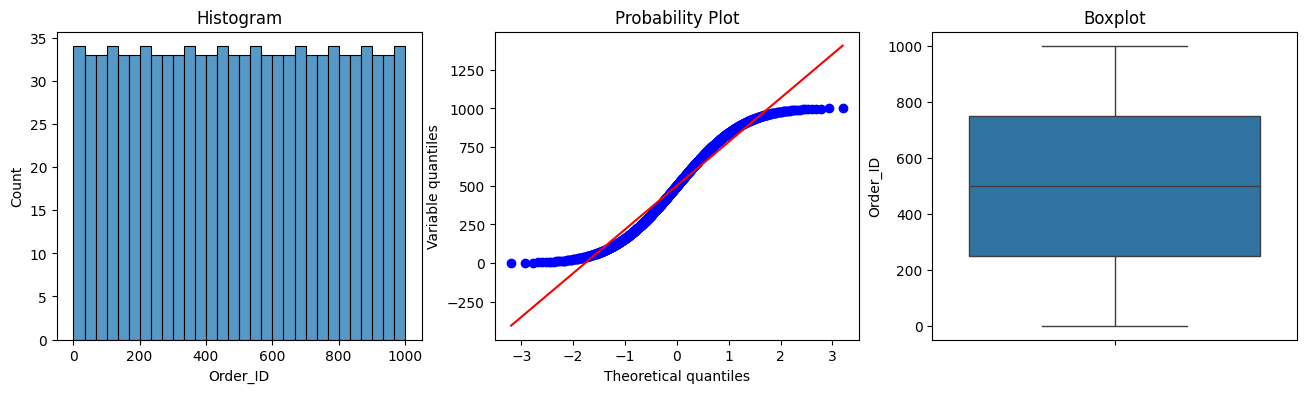

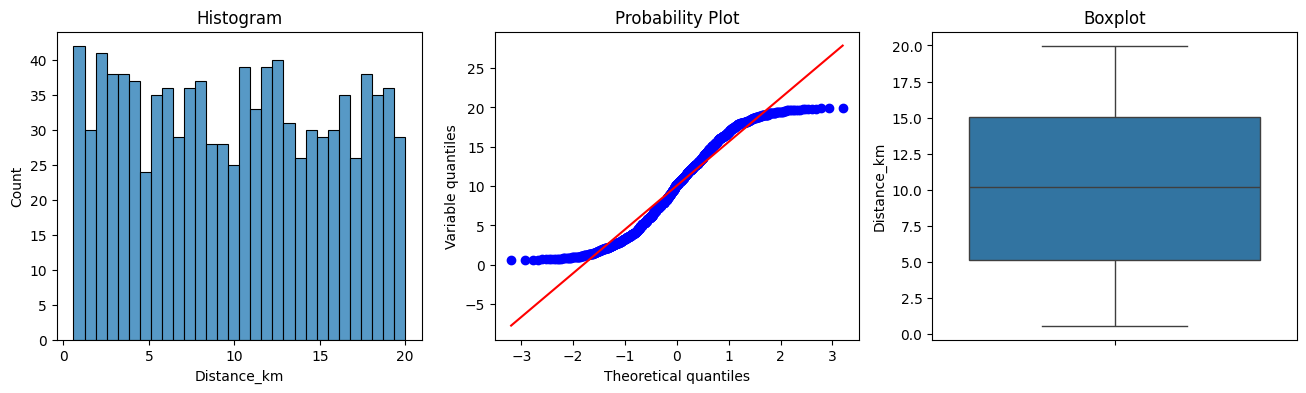

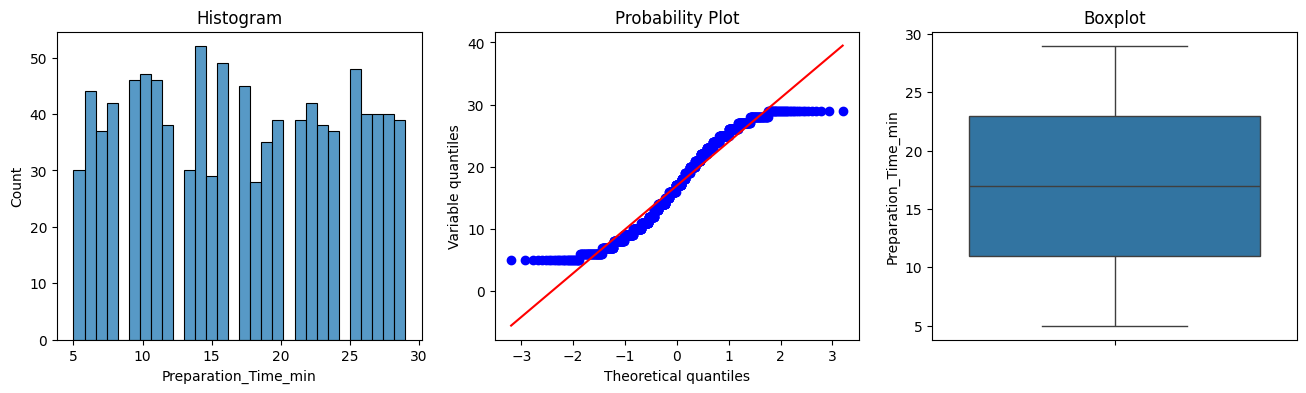

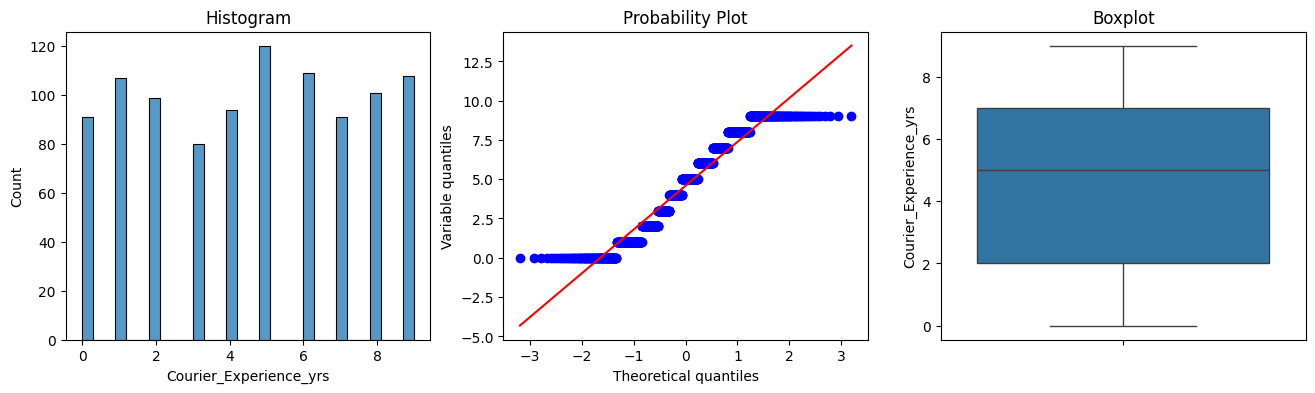

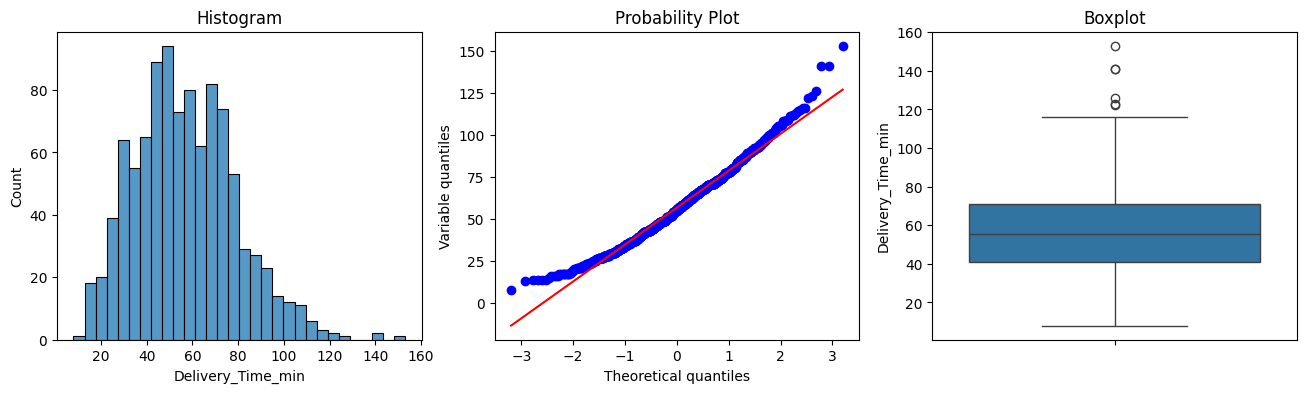

In [23]:
for col in numeric_cols:
    check_plot(df, col)

Outlier

- Terdapat Outlier pada kolom delivery time, yang mana setelah di cek menunjukan nilai yang aktual dan nilai outlier tidak ekstrem.
- Maka outlier tidak akan di handle

# EDA

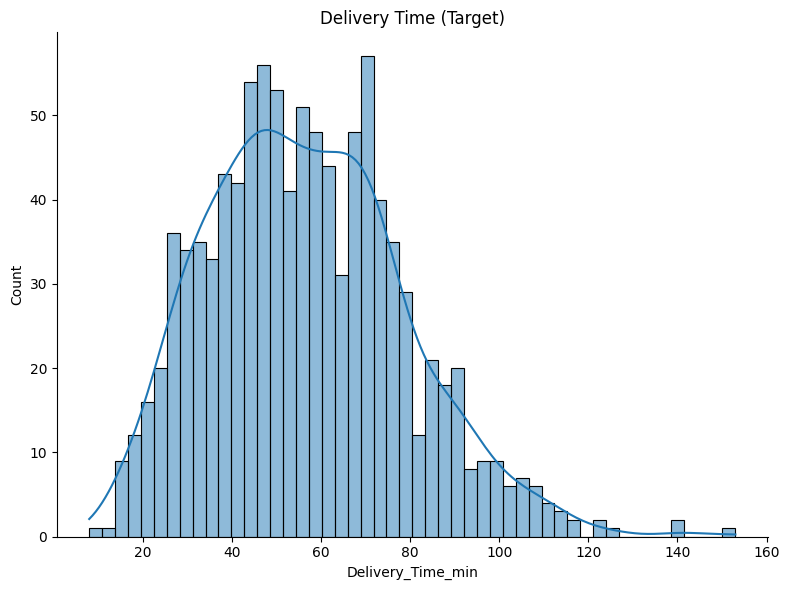

In [24]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Delivery_Time_min'], bins=50, kde=True)
plt.title("Delivery Time (Target)")

sns.despine()
plt.tight_layout()
plt.show()

Insight

- Right-skewed, banyak order selesai di sekitar 40–70 menit, tapi ada ekor panjang ke kanan (>100 menit).

- Ada beberapa outlier (120–150 menit)

- Distribusi ini masuk akal untuk problem delivery/logistics, karena mayoritas pengiriman on-time, tapi sebagian kecil bisa delay.

## Univariate (Categorical)

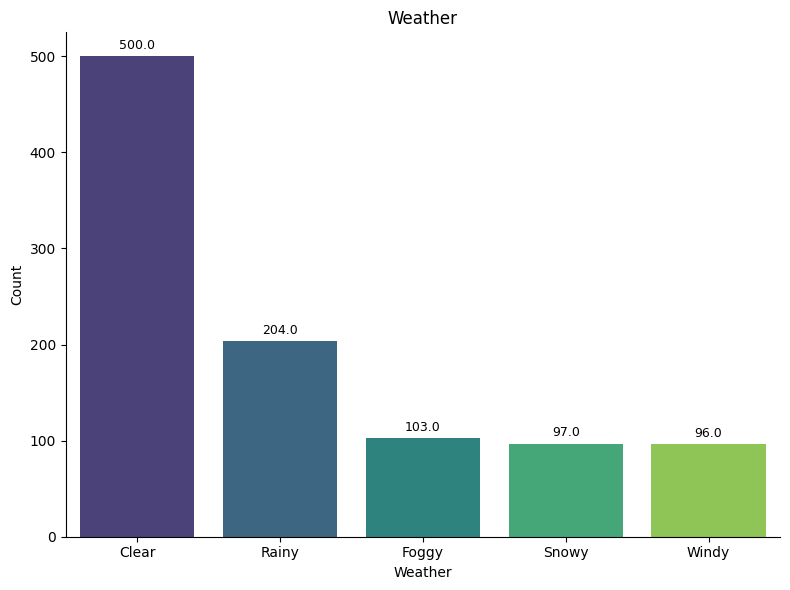

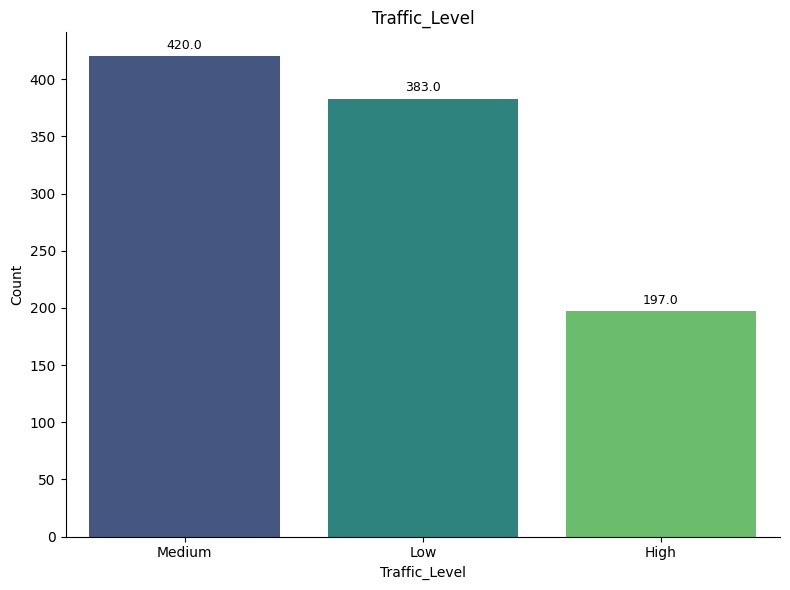

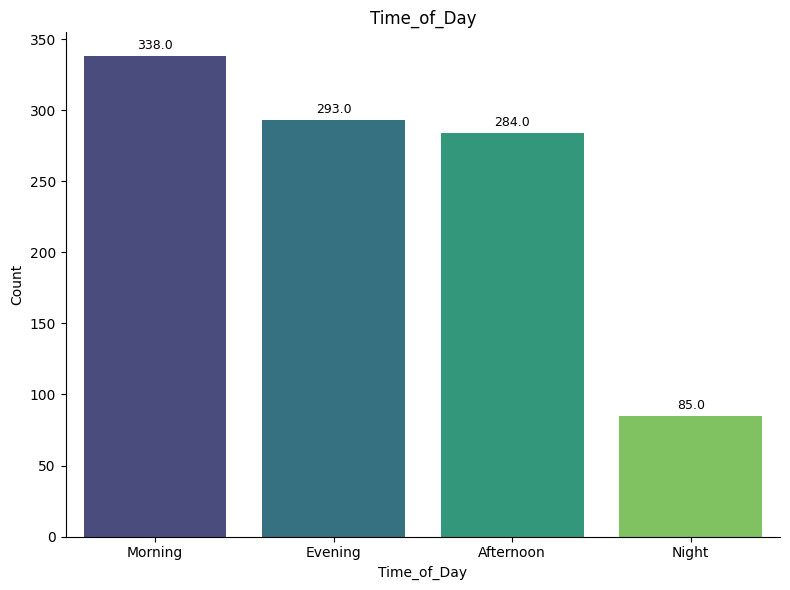

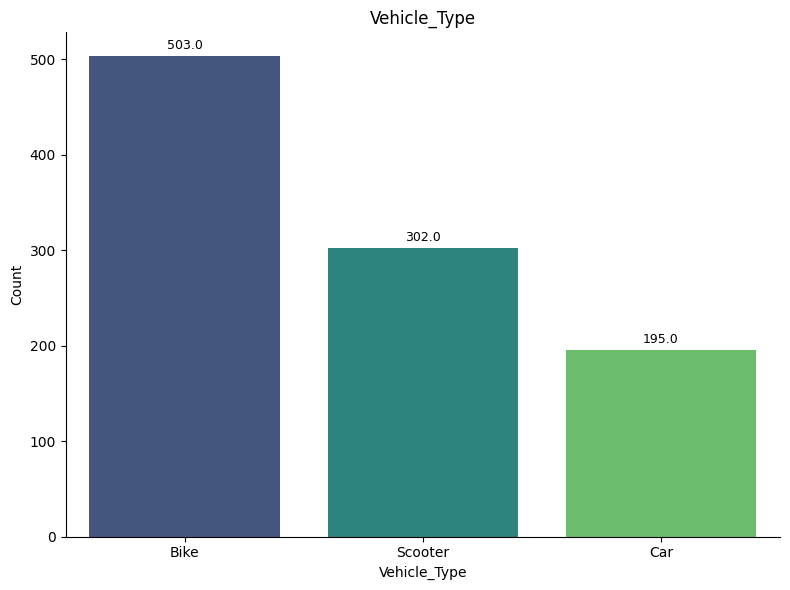

In [25]:
categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

for col in categorical_cols:
    plt.figure(figsize=(8,6))
    ax = sns.countplot(
        x=df[col],
        order=df[col].value_counts().index,
        palette="viridis"
    )
    plt.title(f'{col}')
    plt.xlabel(col)
    plt.ylabel("Count")

    # label di atas bar
    for p in ax.patches:
        ax.annotate(
            f'{p.get_height()}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='bottom',
            fontsize=9, color='black', xytext=(0, 3),
            textcoords='offset points'
        )

    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()

**Weather**

- Clear (500) → setengah dari total order (50%).

- Rainy (204) → cukup banyak (20%).

- Foggy (103), Snowy (97), Windy (96) → relatif seimbang, sekitar 9–10% masing-masing.

**Travic Levels**

- Medium (420) → 42% dari total data.

- Low (383) → 38.3%, hampir seimbang dengan Medium.

- High (197) → hanya 19.7%, paling sedikit.

**Time of Day**

- Morning (338) → paling dominan (33.8%).

- Evening (293) → sekitar 29.3%.

- Afternoon (284) → 28.4%, hampir sama dengan Evening.

- Night (85) → hanya 8.5%, paling sedikit.

**Vehicle Type**

- Bike (503) → paling dominan, 50.3%.

- Scooter (302) → 30.2%.

- Car (195) → 19.5%, paling sedikit.

## Univariate (Numerical)

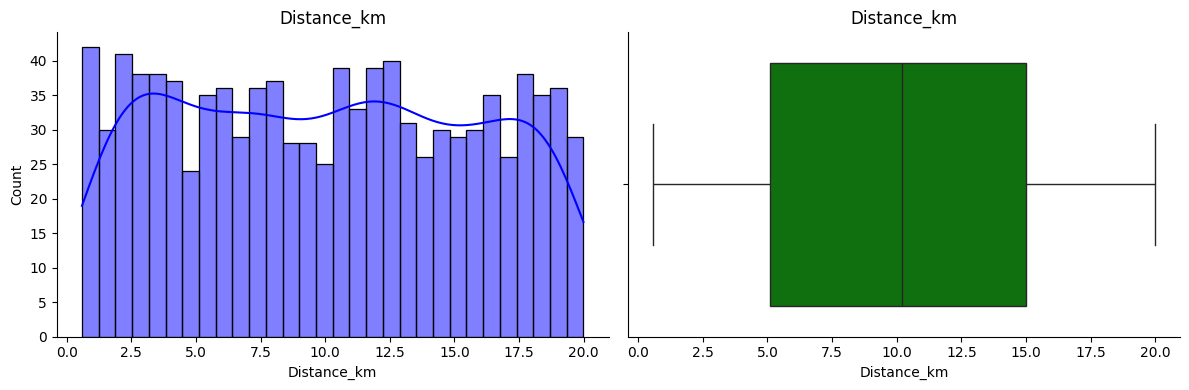

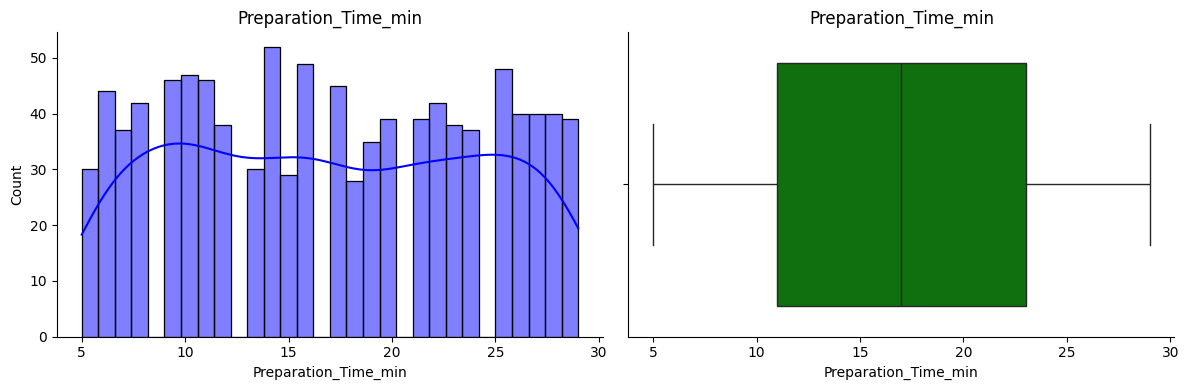

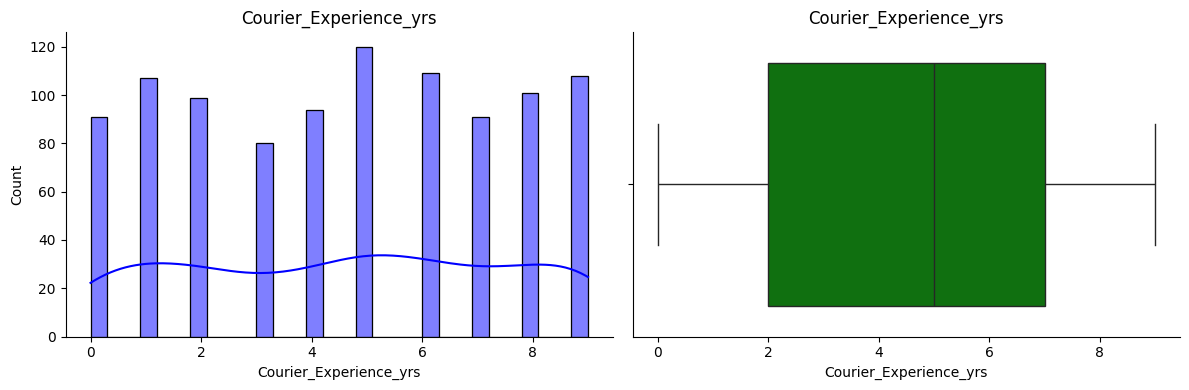

In [26]:
numeric_cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']

for col in numeric_cols:
    plt.figure(figsize=(12,4))

    # Histogram + KDE
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True, bins=30, color="blue")
    plt.title(f'{col}')

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col], color="green")
    plt.title(f'{col}')

    sns.despine()
    plt.tight_layout()
    plt.show()

**Distance**

- Histogram: distribusi relatif merata dari 0.5 km hingga 20 km.

- Median: sekitar 10 km.

- Boxplot: tidak terlihat outlier, data cukup simetris.

**Preparation Time**

- Histogram: distribusi cenderung merata antara 5 – 29 menit, tanpa puncak tertentu.

- Median: sekitar 17 menit.

- Boxplot: tidak ada outlier signifikan, data cukup tersebar rata.

**Courier Experience**

- Histogram: distribusi cukup rata dari 0 hingga 9 tahun, tidak ada lonjakan mencolok.

- Median: sekitar 5 tahun.

- Boxplot: sebaran merata, tanpa outlier.

## Bivariate (Categorical)

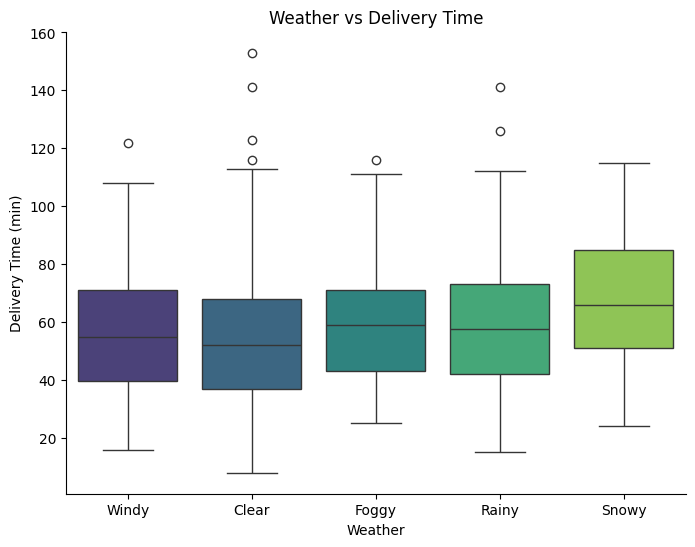

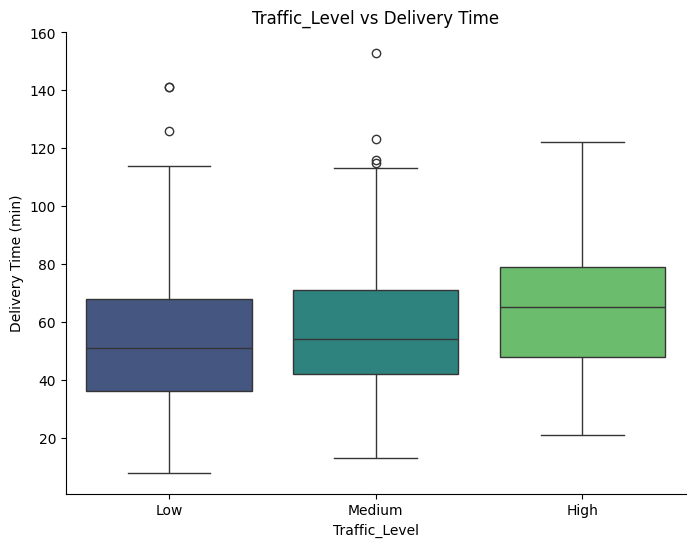

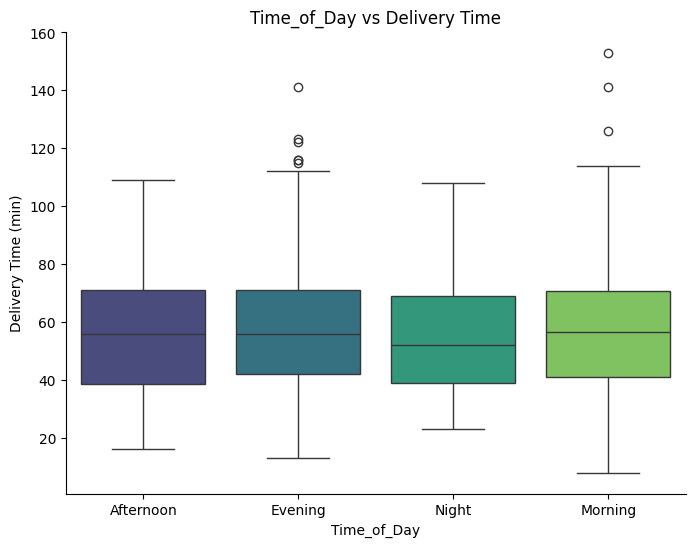

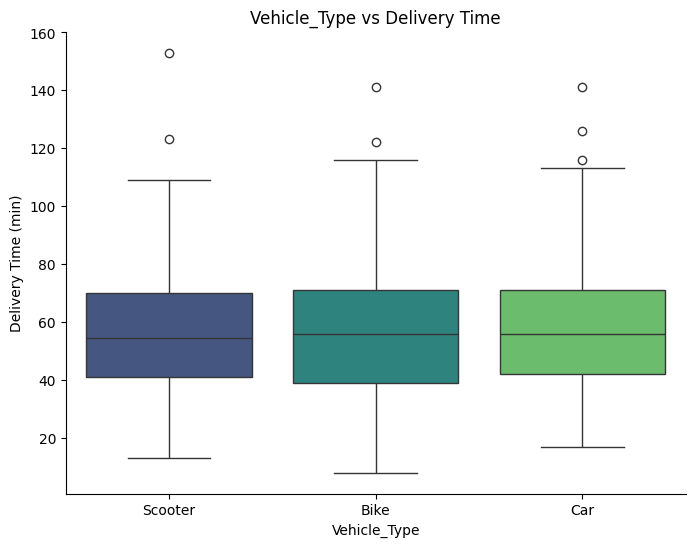

In [27]:
categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

for col in categorical_cols:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[col], y=df['Delivery_Time_min'], palette="viridis")
    plt.title(f'{col} vs Delivery Time')
    plt.ylabel("Delivery Time (min)")
    plt.xlabel(col)
    sns.despine()
    plt.show()

**Weather vs Target**

- Clear, median delivery time relatif paling rendah (~50 menit).

- Rainy & Foggy, median naik sedikit (~57–60 menit).

- Snowy, median tertinggi (~65 menit), dengan sebaran lebih lebar.

- Windy, median juga agak tinggi (~55 menit), tapi sebarannya tidak terlalu lebar.

- Outlier banyak muncul di semua kategori (hingga 150 menit), menunjukkan ada beberapa kasus ekstrem di tiap kondisi cuaca.

**Traffic Level vs Target**

- Low traffic, median sekitar 50 menit, sebaran cukup rapat.

- Medium traffic, median naik sedikit (~53–55 menit), variabilitas lebih lebar.

- High traffic, median paling tinggi (~65 menit), dengan sebaran yang lebih besar.


**Time of Day vs Target**

- Afternoon, median sekitar 55 menit, sebaran sedang.

- Evening, median mirip Afternoon (~55–57 menit), tapi lebih banyak outlier (hingga 140+ menit).

- Night, median sedikit lebih rendah (~50 menit), sebaran lebih rapat.

- Morning, median ~56 menit, tapi variasinya lebih besar (beberapa outlier sampai 150 menit).

**Vehicle Type vs Target**

- Scooter, median sekitar 55 menit, sebaran cukup rapat.

- Bike, median mirip Scooter (~55–56 menit), variasi sedikit lebih lebar.

- Car, median hampir sama (~55 menit), tapi distribusi sedikit lebih tersebar (lebih banyak outlier).

- Secara umum, ketiga jenis kendaraan punya median yang mirip.

## Bivariate (Numerical)

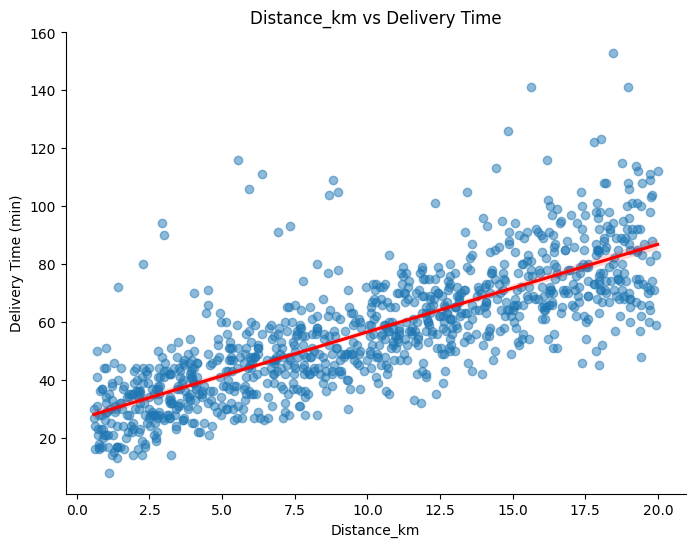

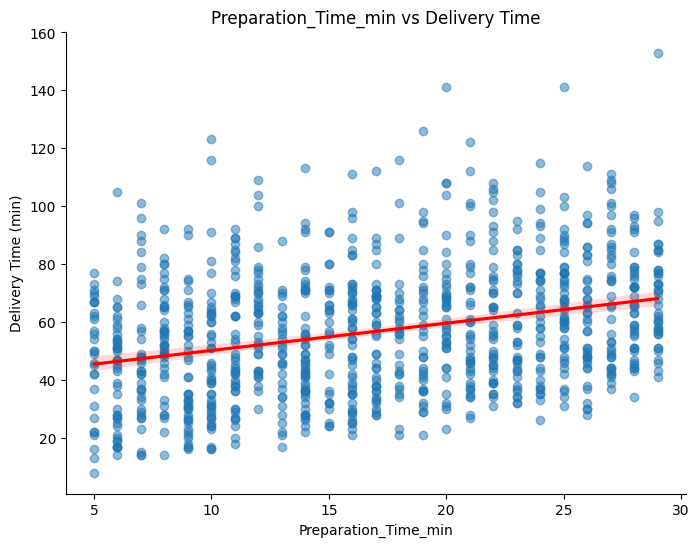

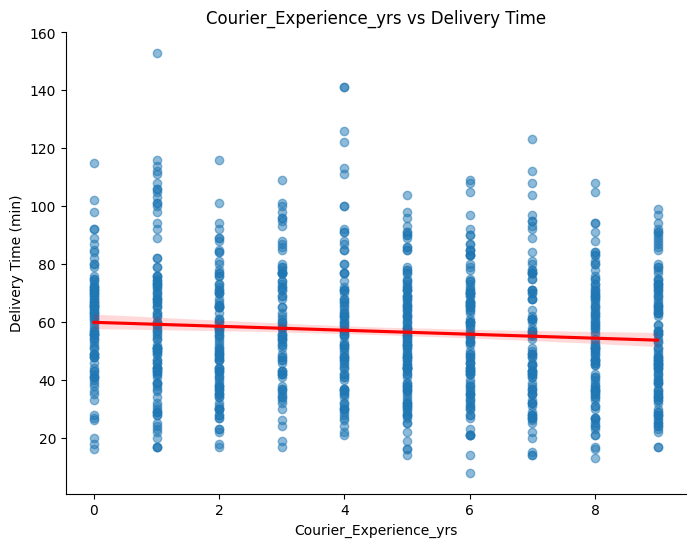

In [28]:
numeric_cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']

for col in numeric_cols:
    plt.figure(figsize=(8,6))
    sns.regplot(x=df[col], y=df['Delivery_Time_min'], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    plt.title(f'{col} vs Delivery Time')
    plt.xlabel(col)
    plt.ylabel("Delivery Time (min)")
    sns.despine()
    plt.show()

**Distance vs Target**

- Scatterplot menunjukkan hubungan positif yang jelas → semakin jauh jaraknya, semakin lama waktu pengiriman.

- Garis regresi (merah) menegaskan tren linear ini.

- Variabilitas makin besar saat jarak tinggi (contoh di 15–20 km, ada yang tetap cepat tapi ada juga yang sangat lama).

**Preparation vs Target**

- Scatterplot menunjukkan hubungan positif, meskipun tidak sekuat Distance_km.

- Garis regresi (merah) naik perlahan, semakin lama preparation, semakin lama delivery.

- Sebaran data cukup lebar di setiap titik preparation, artinya faktor lain juga berperan (misalnya traffic, weather).

**Courier Experience vs Target**

- Scatterplot menunjukkan tren negatif yang sangat lemah.

- Garis regresi (merah) menurun sedikit → semakin berpengalaman kurir, waktu pengiriman agak lebih cepat.

- Tapi sebaran data sangat lebar di semua level pengalaman → ada kurir senior tetap lama, ada kurir baru yang cepat.

## Correlation Heatmap

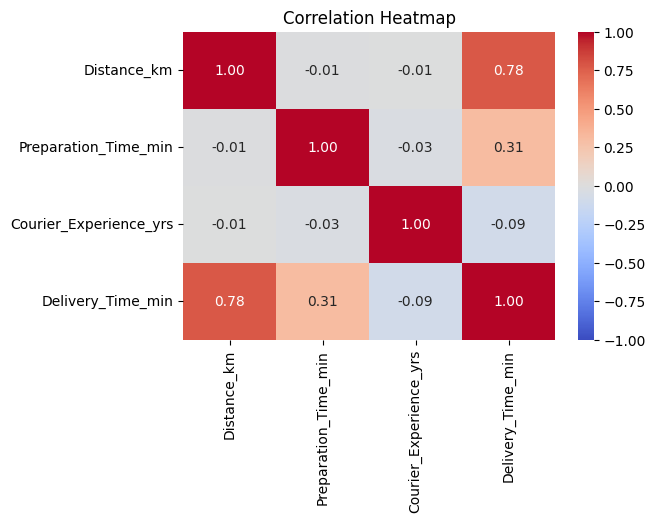

In [29]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Distance_km','Preparation_Time_min','Courier_Experience_yrs','Delivery_Time_min']].corr(),
            annot=True, center=0, vmax=1,vmin=-1, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Insight**

- Distance_km - Delivery_Time_min = 0.78 korelasi kuat semakin jauh jarak, semakin lama waktu kirim.

- Preparation_Time_min - Delivery_Time_min = 0.31 korelasi sedang makin lama persiapan, makin lama delivery.

- Courier_Experience_yrs - Delivery_Time_min = -0.09 korelasi negatif sangat lemah pengalaman kurir hampir tidak memengaruhi.

- Antar fitur numerik (multicollinearity check):
  - Semua nilai antar fitur < 0.1 tidak ada multicollinearity.

# Processing

## Split

In [30]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Order_ID', 'Delivery_Time_min'])
y = df['Delivery_Time_min']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Encoding

In [31]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
numeric_cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

## Scalling

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

preprocessor_with_scaling = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

## Model

### Linear Regression

In [33]:
from sklearn.linear_model import LinearRegression

linreg = Pipeline(steps=[
    ('preprocessor', preprocessor_with_scaling),
    ('regressor', LinearRegression())
])

linreg.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Weather', 'Traffic_Level',
                                                   'Time_of_Day',
                                                   'Vehicle_Type']),
                                                 ('num', StandardScaler(),
                                                  ['Distance_km',
                                                   'Preparation_Time_min',
                                                   'Courier_Experience_yrs'])])),
                ('regressor', LinearRegression())])

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error

y_pred = linreg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print("Linear Regression Performance:")
print(f"MAE   : {mae:.2f} minutes")
print(f"RMSE  : {rmse:.2f} minutes")
print(f"R²    : {r2:.2f}")
print(f"MAPE  : {mape:.2f}%")

Linear Regression Performance:
MAE   : 5.90 minutes
RMSE  : 8.83 minutes
R²    : 0.83
MAPE  : 10.41%


**Insight**

- MAE : 5.90 menit → rata-rata meleset ~6 menit.

- RMSE : 8.83 menit → ada beberapa error besar (karena RMSE > MAE).

- R² : 0.83 → model bisa menjelaskan 83% variasi dalam delivery time.

- MAPE : 10.41% → prediksi rata-rata meleset sekitar 10% dari waktu aktual.

### Random Forest

In [36]:
from sklearn.ensemble import RandomForestRegressor

rf = Pipeline(steps=[
    ('preprocessor', preprocessor),  # tanpa scaling, karena RF ga butuh scaling
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Weather', 'Traffic_Level',
                                                   'Time_of_Day',
                                                   'Vehicle_Type']),
                                                 ('num', 'passthrough',
                                                  ['Distance_km',
                                                   'Preparation_Time_min',
                                                   'Courier_Experience_yrs'])])),
                ('regressor',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [37]:
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf) * 100

print("Random Forest Performance:")
print(f"MAE   : {mae_rf:.2f} minutes")
print(f"RMSE  : {rmse_rf:.2f} minutes")
print(f"R²    : {r2_rf:.2f}")
print(f"MAPE  : {mape_rf:.2f}%")

Random Forest Performance:
MAE   : 7.02 minutes
RMSE  : 10.21 minutes
R²    : 0.77
MAPE  : 13.05%


**Insight**

- MAE : 7.02 min (lebih buruk dari Linear Regression: 5.9 min)

- RMSE : 10.21 min (lebih tinggi, berarti lebih banyak error besar)

- R² : 0.77 (lebih rendah, berarti lebih sedikit variasi yang dijelaskan)

- MAPE : 13.05% (lebih buruk dari 10.41%)

### XGBoost

In [39]:
from xgboost import XGBRegressor

xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),  # tanpa scaling, XGB juga tidak perlu scaling
    ('regressor', XGBRegressor(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

xgb.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Weather', 'Traffic_Level',
                                                   'Time_of_Day',
                                                   'Vehicle_Type']),
                                                 ('num', 'passthrough',
                                                  ['Distance_km',
                                                   'Preparation_Time_min',
                                                   'Courier_Experience_yrs'])])),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=300, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [40]:
y_pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)
mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb) * 100

print("XGBoost Performance:")
print(f"MAE   : {mae_xgb:.2f} minutes")
print(f"RMSE  : {rmse_xgb:.2f} minutes")
print(f"R²    : {r2_xgb:.2f}")
print(f"MAPE  : {mape_xgb:.2f}%")

XGBoost Performance:
MAE   : 7.02 minutes
RMSE  : 10.08 minutes
R²    : 0.77
MAPE  : 12.92%


**Insight**

- MAE : 7.02 min (sama seperti RF, lebih buruk dari Linear Regression).

- RMSE : 10.08 min (mirip RF, lebih besar dari Linear Regression).

- R² : 0.77 (lebih rendah dari Linear Regression 0.83).

- MAPE : 12.92% (lebih buruk dari Linear Regression 10.41%).

## Hyperparameter Tuning

### Ridge Lasso

In [42]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

In [43]:
# Ridge
ridge_pipe = Pipeline([('pre', preprocessor_with_scaling), ('reg', Ridge())])
ridge_grid = {'reg__alpha': [0.1, 0.5, 1, 2, 5, 10]}

ridge_cv = GridSearchCV(
    ridge_pipe, ridge_grid, scoring='neg_mean_absolute_error',
    cv=5, n_jobs=-1, verbose=0
)
ridge_cv.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['Weather',
                                                                          'Traffic_Level',
                                                                          'Time_of_Day',
                                                                          'Vehicle_Type']),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         ['Distance_km',
                                                                          'Preparation_Time_min',
                                                                          'Courier_Experience_yrs'])])),
                                       ('reg', Ridge())]),
             n_jobs=-1, param_grid={'reg__alpha': [0.1, 0.5, 1, 2, 5, 10]},
             scoring='neg_mean_absolute_error')

In [44]:
# Eval Ridge
y_pred_ridge = ridge_cv.best_estimator_.predict(X_test)
ridge_res = {
    "Model": "Ridge",
    "Best Params": ridge_cv.best_params_,
    "CV best (−MAE)": -ridge_cv.best_score_,
    "MAE (min)": mean_absolute_error(y_test, y_pred_ridge),
    "RMSE (min)": np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
    "R2": r2_score(y_test, y_pred_ridge),
    "MAPE (%)": mean_absolute_percentage_error(y_test, y_pred_ridge)*100
}

In [45]:
# Lasso
lasso_pipe = Pipeline([('pre', preprocessor_with_scaling), ('reg', Lasso(max_iter=10000))])
lasso_grid = {'reg__alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1]}

lasso_cv = GridSearchCV(
    lasso_pipe, lasso_grid, scoring='neg_mean_absolute_error',
    cv=5, n_jobs=-1, verbose=0
)
lasso_cv.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['Weather',
                                                                          'Traffic_Level',
                                                                          'Time_of_Day',
                                                                          'Vehicle_Type']),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         ['Distance_km',
                                                                          'Preparation_Time_min',
                                                                          'Courier_Experience_yrs'])])),
                                       ('reg', Lasso(max_iter=10000))]),
             n_jobs=-1,
             param_grid={'reg__alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1]},
             scoring='neg_mean_absolute_error')

In [46]:
# Eval Lasso
y_pred_lasso = lasso_cv.best_estimator_.predict(X_test)
lasso_res = {
    "Model": "Lasso",
    "Best Params": lasso_cv.best_params_,
    "CV best (−MAE)": -lasso_cv.best_score_,
    "MAE (min)": mean_absolute_error(y_test, y_pred_lasso),
    "RMSE (min)": np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
    "R2": r2_score(y_test, y_pred_lasso),
    "MAPE (%)": mean_absolute_percentage_error(y_test, y_pred_lasso)*100
}

pd.DataFrame([ridge_res, lasso_res]).sort_values("MAE (min)")

,Model,Best Params,CV best (−MAE),MAE (min),RMSE (min),R2,MAPE (%)
0,Ridge,{'reg__alpha': 0.1},6.744536,5.900499,8.828044,0.826127,10.412023
1,Lasso,{'reg__alpha': 0.001},6.744440,5.900668,8.828147,0.826123,10.412236


**Insight**

1. Ridge (α=0.1)

- MAE: 5.90 min

- RMSE: 8.83 min

- R²: 0.826

- MAPE: 10.41%

2. Lasso (α=0.001)

- MAE: 5.90 min

- RMSE: 8.83 min

- R²: 0.826

- MAPE: 10.41%

- Performanya identik dengan Linear Regression biasa. Artinya regularisasi tidak banyak membantu.

- Ridge & Lasso tetap useful sebagai sanity check: mereka mengonfirmasi bahwa model linear memang sudah optimal.

### Elastic Net

In [73]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [76]:
en_pipe = Pipeline([
    ("preprocessor", preprocessor_with_scaling),  # sama persis seperti di linreg
    ("regressor", ElasticNet(max_iter=10000, random_state=42))
])

# === Grid hyperparameter ===
en_grid = {
    "regressor__alpha": [0.001, 0.01, 0.1, 1.0, 10.0],
    "regressor__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

# === GridSearchCV pakai MAE (biar konsisten) ===
en_cv = GridSearchCV(
    estimator=en_pipe,
    param_grid=en_grid,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Train
en_cv.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['Weather',
                                                                          'Traffic_Level',
                                                                          'Time_of_Day',
                                                                          'Vehicle_Type']),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         ['Distance_km',
                                                                          'Preparation_Time_min',
                                                                          'Courier_Experience_yrs'])])),
                                       ('regressor',
                                        ElasticNet(max_iter=10000,
                                                   random_state=42))]),
             n_jobs=-1,
             param_grid={'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
                         'regressor__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
             scoring='neg_mean_absolute_error', verbose=1)

In [77]:
# Best model & evaluasi
best_en = en_cv.best_estimator_
y_pred_en = best_en.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred_en)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_en))
r2   = r2_score(y_test, y_pred_en)
mape = mean_absolute_percentage_error(y_test, y_pred_en) * 100

print("ElasticNet — Best Params:", en_cv.best_params_)
print(f"ElasticNet — CV best (-MAE): {-en_cv.best_score_:.3f}")
print("\nElasticNet (tuned) — Test Metrics")
print(f"MAE   : {mae:.2f} minutes")
print(f"RMSE  : {rmse:.2f} minutes")
print(f"R²    : {r2:.2f}")
print(f"MAPE  : {mape:.2f}%")

ElasticNet — Best Params: {'regressor__alpha': 0.001, 'regressor__l1_ratio': 0.9}
ElasticNet — CV best (-MAE): 6.744

ElasticNet (tuned) — Test Metrics
MAE   : 5.90 minutes
RMSE  : 8.83 minutes
R²    : 0.83
MAPE  : 10.42%


MAE = 5.90 menit

RMSE = 8.83 menit

R² = 0.83

MAPE = 10.42%

Hampir identik dengan baseline Linear Regression, tapi dengan keuntungan regularisasi → lebih tahan terhadap overfitting dan outlier, apalagi kalau dataset lebih besar/kompleks.

### Random Forest

In [47]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

In [48]:
# Pipeline RF (tanpa scaling)
rf_pipe = Pipeline([
    ('pre', preprocessor),  # OHE untuk kategori, numerik passthrough
    ('reg', RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        bootstrap=True
    ))
])

In [49]:
# Grid yang efektif
rf_grid = {
    'reg__n_estimators': [100, 200, 300],
    'reg__max_depth': [None, 10, 20, 30],
    'reg__min_samples_split': [2, 5, 10],
    'reg__min_samples_leaf': [1, 2, 4],
    'reg__max_features': ['sqrt', 'log2', 0.8]  # 0.8 = 80% fitur
}

rf_cv = GridSearchCV(
    rf_pipe,
    rf_grid,
    scoring='neg_mean_absolute_error',  # pakai MAE
    cv=5,
    n_jobs=-1,
    verbose=0
)

rf_cv.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['Weather',
                                                                          'Traffic_Level',
                                                                          'Time_of_Day',
                                                                          'Vehicle_Type']),
                                                                        ('num',
                                                                         'passthrough',
                                                                         ['Distance_km',
                                                                          'Preparation_Time_min',
                                                                          'Courier_Experience_yrs'])])),
                                       ('reg',
                                        RandomForestRegressor(n_jobs=-1,
                                                              random_state=42))]),
             n_jobs=-1,
             param_grid={'reg__max_depth': [None, 10, 20, 30],
                         'reg__max_features': ['sqrt', 'log2', 0.8],
                         'reg__min_samples_leaf': [1, 2, 4],
                         'reg__min_samples_split': [2, 5, 10],
                         'reg__n_estimators': [100, 200, 300]},
             scoring='neg_mean_absolute_error')

In [50]:
# Evaluasi di test set
best_rf = rf_cv.best_estimator_
y_pred_rf = best_rf.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2   = r2_score(y_test, y_pred_rf)
mape = mean_absolute_percentage_error(y_test, y_pred_rf) * 100

print("Best RF params:", rf_cv.best_params_)
print(f"CV best (−MAE): {-rf_cv.best_score_:.3f}")
print("\nRandom Forest (tuned) — Test Metrics")
print(f"MAE   : {mae:.2f} minutes")
print(f"RMSE  : {rmse:.2f} minutes")
print(f"R²    : {r2:.2f}")
print(f"MAPE  : {mape:.2f}%")

Best RF params: {'reg__max_depth': None, 'reg__max_features': 0.8, 'reg__min_samples_leaf': 4, 'reg__min_samples_split': 2, 'reg__n_estimators': 200}
CV best (−MAE): 7.842

Random Forest (tuned) — Test Metrics
MAE   : 6.99 minutes
RMSE  : 10.13 minutes
R²    : 0.77
MAPE  : 13.27%


1. Perbandingan dengan baseline RF (sebelum tuning)

- Baseline RF → MAE: 7.02, RMSE: 10.21, R²: 0.77, MAPE: 13.05%

- Tuning RF → MAE: 6.99, RMSE: 10.13, R²: 0.77, MAPE: 13.27%

2. Insight

- Performansi nyaris sama dengan baseline.

- Ada sedikit perbaikan di MAE & RMSE, tapi MAPE justru naik tipis.

- Artinya: dataset ini memang cukup well-fitted dengan setting default Random Forest, jadi tuning tidak memberikan lonjakan signifikan.

- Parameternya cenderung memilih model lebih sederhana (leaf=4, split=5) → artinya model menghindari overfitting, tapi tetap performa mirip.

### XGBoost

In [51]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

xgb_pipe = Pipeline([
    ('pre', preprocessor),  # OHE kategori, numerik passthrough
    ('reg', XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        tree_method='hist'  # cepat
    ))
])

In [52]:
xgb_grid = {
    'reg__n_estimators': [100, 200, 300],
    'reg__learning_rate': [0.05, 0.1],
    'reg__max_depth': [4, 6, 8],
    'reg__subsample': [0.7, 0.9, 1.0],
    'reg__colsample_bytree': [0.7, 0.9, 1.0],
    'reg__reg_alpha': [0, 0.1],
    'reg__reg_lambda': [1, 2]
}

xgb_cv = GridSearchCV(
    xgb_pipe, xgb_grid,
    scoring='neg_mean_absolute_error',
    cv=5, n_jobs=-1, verbose=0
)
xgb_cv.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['Weather',
                                                                          'Traffic_Level',
                                                                          'Time_of_Day',
                                                                          'Vehicle_Type']),
                                                                        ('num',
                                                                         'passthrough',
                                                                         ['Distance_km',
                                                                          'Preparation_Time_min',
                                                                          'Courier_Experience_yrs'])])),
                                       ('reg',
                                        XGBRegressor(base_score=None,
                                                     booster=None,
                                                     callbacks=No...
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=-1,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'reg__colsample_bytree': [0.7, 0.9, 1.0],
                         'reg__learning_rate': [0.05, 0.1],
                         'reg__max_depth': [4, 6, 8],
                         'reg__n_estimators': [100, 200, 300],
                         'reg__reg_alpha': [0, 0.1], 'reg__reg_lambda': [1, 2],
                         'reg__subsample': [0.7, 0.9, 1.0]},
             scoring='neg_mean_absolute_error')

In [53]:
best_xgb = xgb_cv.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2   = r2_score(y_test, y_pred_xgb)
mape = mean_absolute_percentage_error(y_test, y_pred_xgb) * 100

print("Best XGB params:", xgb_cv.best_params_)
print(f"CV best (−MAE): {-xgb_cv.best_score_:.3f}")
print("\nXGBoost (tuned) — Test Metrics")
print(f"MAE   : {mae:.2f} minutes")
print(f"RMSE  : {rmse:.2f} minutes")
print(f"R²    : {r2:.2f}")
print(f"MAPE  : {mape:.2f}%")

Best XGB params: {'reg__colsample_bytree': 0.9, 'reg__learning_rate': 0.05, 'reg__max_depth': 4, 'reg__n_estimators': 100, 'reg__reg_alpha': 0, 'reg__reg_lambda': 2, 'reg__subsample': 0.7}
CV best (−MAE): 7.483

XGBoost (tuned) — Test Metrics
MAE   : 6.50 minutes
RMSE  : 9.47 minutes
R²    : 0.80
MAPE  : 12.16%


1. Hasil Evaluasi

- MAE: 6.50 menit

- RMSE: 9.47 menit

- R²: 0.80

- MAPE: 12.16%

2. Dibandingkan:

- Linear Regression → R² = 0.83, MAE lebih rendah (5.90).

- Random Forest (tuned) → R² = 0.77, MAE = 6.99.

- XGBoost (tuned) → R² = 0.80, MAE = 6.50 → lebih baik dari RF, tapi masih sedikit di bawah Linear Regression untuk akurasi murni.

## Actual vs Predict

### Linear Regression

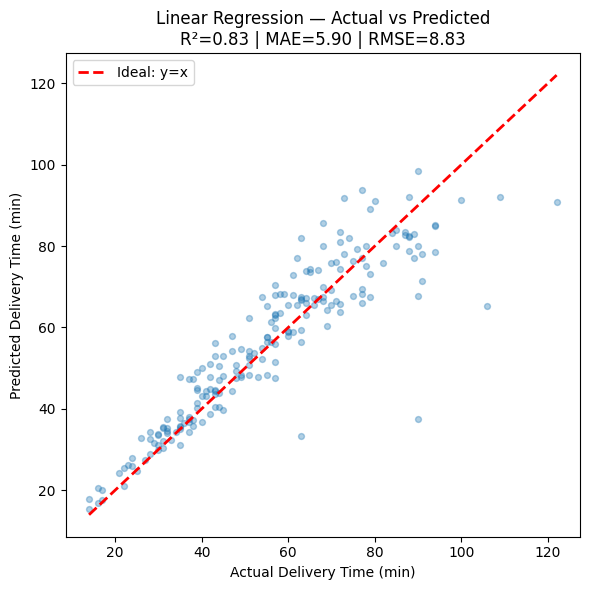

In [70]:
# === Prediksi & metrik (Linear Regression) ===
y_pred_lin = linreg.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred_lin)
rmse = np.sqrt(((y_test - y_pred_lin)**2).mean())
r2   = r2_score(y_test, y_pred_lin)

minv, maxv = y_test.min(), y_test.max()

# 1) SCATTER: Actual vs Predicted + garis ideal
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lin, alpha=0.35, s=18)
plt.plot([minv, maxv], [minv, maxv], 'r--', lw=2, label='Ideal: y=x')
plt.xlabel("Actual Delivery Time (min)")
plt.ylabel("Predicted Delivery Time (min)")
plt.title(f"Linear Regression — Actual vs Predicted\nR²={r2:.2f} | MAE={mae:.2f} | RMSE={rmse:.2f}")
plt.legend()
plt.tight_layout()
plt.show()

- Titik-titik tersebar cukup dekat dengan garis ideal (y=x)

- Pada range delivery time rendah (20–50 menit), prediksi cenderung presisi (titik lebih rapat ke garis).

- Pada delivery time tinggi (>80 menit), mulai muncul penyebaran yang lebih lebar → model kesulitan menangkap kondisi ekstrem (outlier atau perjalanan jauh).

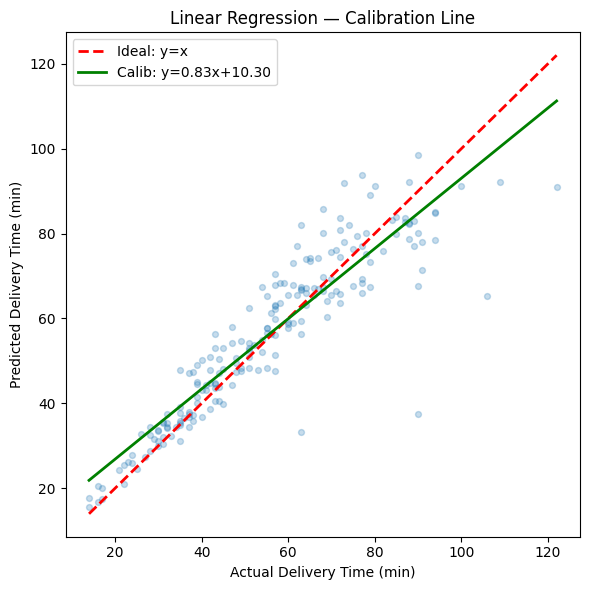

In [71]:
# 2) CALIBRATION LINE: fit linier y_pred ~ y_actual
slope, intercept = np.polyfit(y_test, y_pred_lin, 1)
xline = np.linspace(minv, maxv, 100)
yline = slope * xline + intercept

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lin, alpha=0.25, s=18)
plt.plot([minv, maxv], [minv, maxv], 'r--', lw=2, label='Ideal: y=x')
plt.plot(xline, yline, 'g-', lw=2, label=f'Calib: y={slope:.2f}x+{intercept:.2f}')
plt.xlabel("Actual Delivery Time (min)")
plt.ylabel("Predicted Delivery Time (min)")
plt.title("Linear Regression — Calibration Line")
plt.legend()
plt.tight_layout()
plt.show()

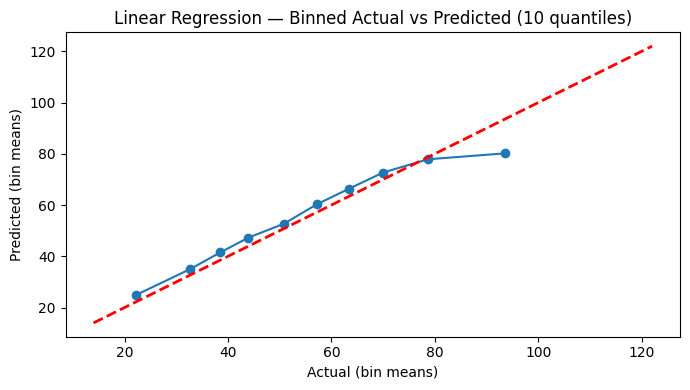

In [72]:
# 3) BINNED ACTUAL vs PREDICTED (10 quantiles by actual)
q = np.quantile(y_test, np.linspace(0, 1, 11))   # edges 10 bin
bins = np.digitize(y_test, q[1:-1])              # bin index 0..9

pred_mean = [y_pred_lin[bins == i].mean() for i in range(10)]
act_mean  = [y_test[bins == i].mean()    for i in range(10)]

plt.figure(figsize=(7,4))
plt.plot(act_mean, pred_mean, marker='o')
plt.plot([minv, maxv], [minv, maxv], 'r--', lw=2)
plt.xlabel("Actual (bin means)")
plt.ylabel("Predicted (bin means)")
plt.title("Linear Regression — Binned Actual vs Predicted (10 quantiles)")
plt.tight_layout()
plt.show()

### Random Forest

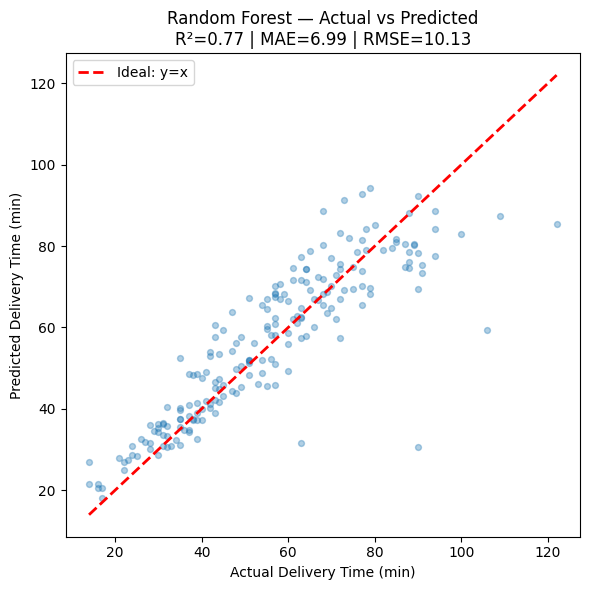

In [55]:
y_pred_rf = best_rf.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2   = r2_score(y_test, y_pred_rf)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.35, s=18)
minv, maxv = y_test.min(), y_test.max()
plt.plot([minv, maxv],[minv, maxv], 'r--', lw=2, label='Ideal: y=x')
plt.xlabel('Actual Delivery Time (min)')
plt.ylabel('Predicted Delivery Time (min)')
plt.title(f'Random Forest — Actual vs Predicted\nR²={r2:.2f} | MAE={mae:.2f} | RMSE={rmse:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

- Titik-titik masih mengikuti pola garis ideal, tapi penyebarannya lebih lebar dibanding Linear Regression.

- Untuk delivery time rendah (20–50 menit), prediksi cukup rapat.

- Untuk delivery time tinggi (>80 menit), prediksi cenderung underpredict (lebih rendah dari aktual).

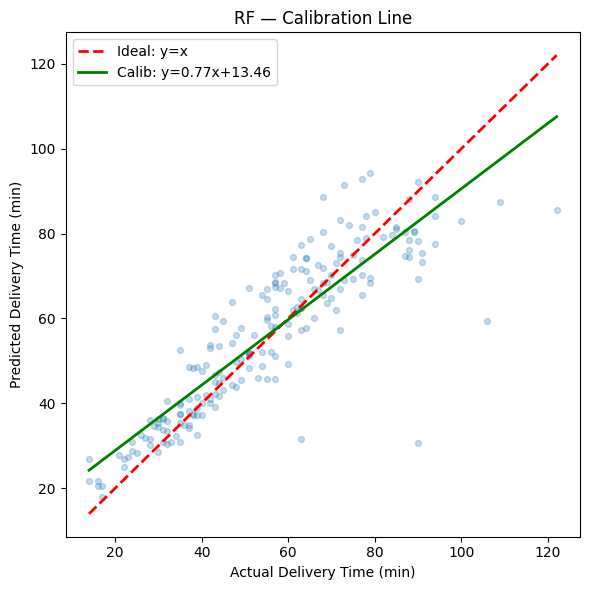

In [56]:
coef = np.polyfit(y_test, y_pred_rf, 1)   # slope, intercept
xline = np.linspace(minv, maxv, 100)
yline = coef[0]*xline + coef[1]

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.25, s=18)
plt.plot([minv, maxv],[minv, maxv], 'r--', lw=2, label='Ideal: y=x')
plt.plot(xline, yline, 'g-', lw=2, label=f'Calib: y={coef[0]:.2f}x+{coef[1]:.2f}')
plt.xlabel('Actual Delivery Time (min)')
plt.ylabel('Predicted Delivery Time (min)')
plt.title('RF — Calibration Line')
plt.legend()
plt.tight_layout()
plt.show()

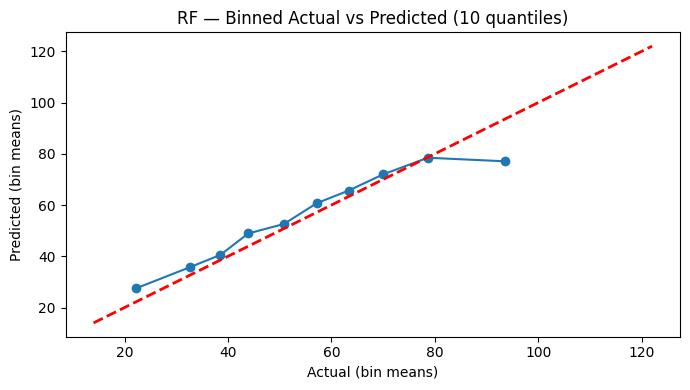

In [57]:
q = np.quantile(y_test, np.linspace(0,1,11))  # 10 bins
bins = np.digitize(y_test, q[1:-1])           # assign bin 0..9
pred_mean = [y_pred_rf[bins==i].mean() for i in range(10)]
act_mean  = [y_test[bins==i].mean()   for i in range(10)]

plt.figure(figsize=(7,4))
plt.plot(act_mean, pred_mean, marker='o')
plt.plot([minv, maxv],[minv, maxv], 'r--', lw=2)
plt.xlabel('Actual (bin means)')
plt.ylabel('Predicted (bin means)')
plt.title('RF — Binned Actual vs Predicted (10 quantiles)')
plt.tight_layout()
plt.show()

### XGBoost

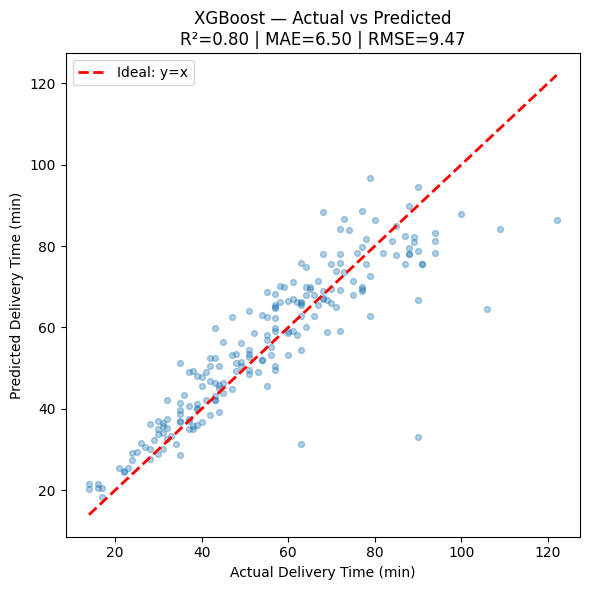

In [58]:
y_pred_xgb = best_xgb.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2   = r2_score(y_test, y_pred_xgb)

# 1) SCATTER: Actual vs Predicted + garis ideal
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.35, s=18)
minv, maxv = y_test.min(), y_test.max()
plt.plot([minv, maxv],[minv, maxv], 'r--', lw=2, label='Ideal: y=x')
plt.xlabel('Actual Delivery Time (min)')
plt.ylabel('Predicted Delivery Time (min)')
plt.title(f'XGBoost — Actual vs Predicted\nR²={r2:.2f} | MAE={mae:.2f} | RMSE={rmse:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

- Titik-titik cukup rapat mengikuti garis ideal (y=x).

- Pada delivery time rendah (20–50 menit) → prediksi cukup akurat, titik dekat dengan garis merah.

- Pada delivery time tinggi (>80 menit) → masih ada kecenderungan underpredict (prediksi lebih rendah dari aktual), meskipun lebih baik daripada RF.

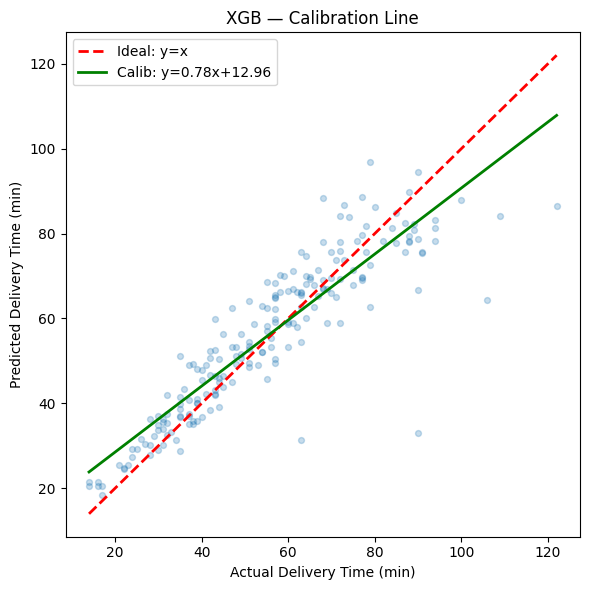

In [59]:
# 2) Garis kalibrasi (fit linier y_pred ~ y_actual)
coef = np.polyfit(y_test, y_pred_xgb, 1)   # slope, intercept
xline = np.linspace(minv, maxv, 100)
yline = coef[0]*xline + coef[1]

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.25, s=18)
plt.plot([minv, maxv],[minv, maxv], 'r--', lw=2, label='Ideal: y=x')
plt.plot(xline, yline, 'g-', lw=2, label=f'Calib: y={coef[0]:.2f}x+{coef[1]:.2f}')
plt.xlabel('Actual Delivery Time (min)')
plt.ylabel('Predicted Delivery Time (min)')
plt.title('XGB — Calibration Line')
plt.legend()
plt.tight_layout()
plt.show()

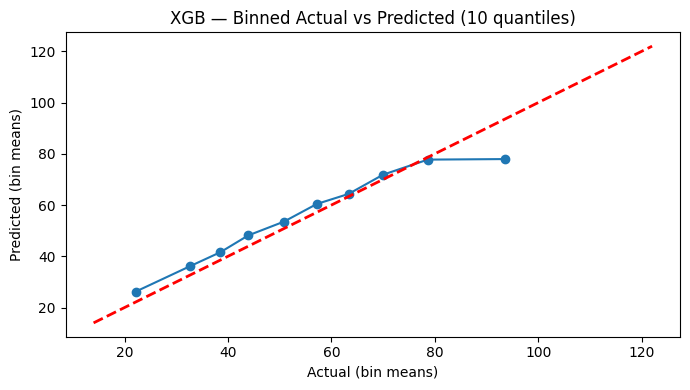

In [60]:
# 3) Binned plot: rata-rata prediksi per quantile actual
q = np.quantile(y_test, np.linspace(0,1,11))  # 10 bins
bins = np.digitize(y_test, q[1:-1])           # assign bin 0..9
pred_mean = [y_pred_xgb[bins==i].mean() for i in range(10)]
act_mean  = [y_test[bins==i].mean()   for i in range(10)]

plt.figure(figsize=(7,4))
plt.plot(act_mean, pred_mean, marker='o')
plt.plot([minv, maxv],[minv, maxv], 'r--', lw=2)
plt.xlabel('Actual (bin means)')
plt.ylabel('Predicted (bin means)')
plt.title('XGB — Binned Actual vs Predicted (10 quantiles)')
plt.tight_layout()
plt.show()

## Residual Plot

### Linear Regression

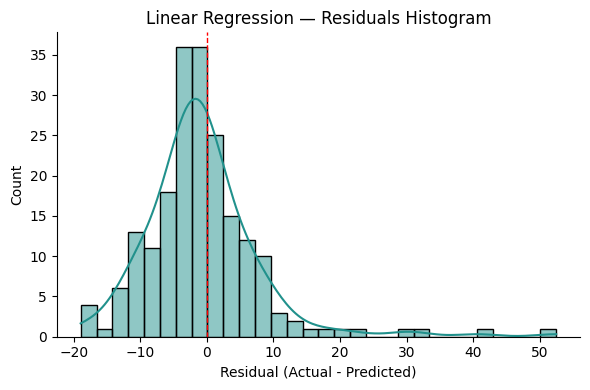

In [61]:
# --- Prediksi Linear Regression ---
y_pred_lin = linreg.predict(X_test)
resid_lin  = y_test - y_pred_lin
fitted_lin = y_pred_lin

# 1) Histogram residual
plt.figure(figsize=(6,4))
sns.histplot(resid_lin, kde=True, bins=30, color=sns.color_palette("viridis", 3)[1])
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.title("Linear Regression — Residuals Histogram")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
sns.despine()
plt.tight_layout()
plt.show()

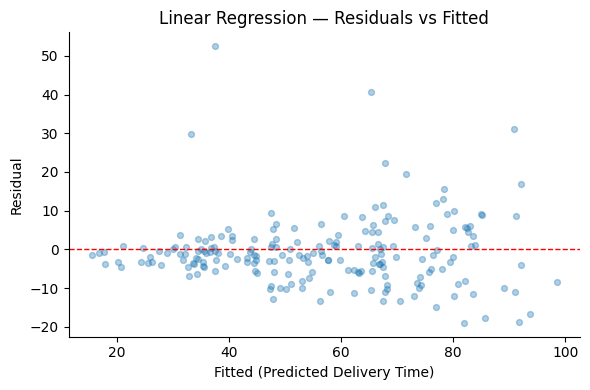

In [62]:
# 2) Residuals vs Fitted
plt.figure(figsize=(6,4))
plt.scatter(fitted_lin, resid_lin, alpha=0.35, s=18)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Linear Regression — Residuals vs Fitted")
plt.xlabel("Fitted (Predicted Delivery Time)")
plt.ylabel("Residual")
sns.despine()
plt.tight_layout()
plt.show()

- Linear Regression cukup solid, residual acak dan tidak menunjukkan pola sistematis → asumsi regresi linear mostly terpenuhi.

- Kelemahan kecil muncul di prediksi waktu tinggi, di mana error menjadi lebih besar.

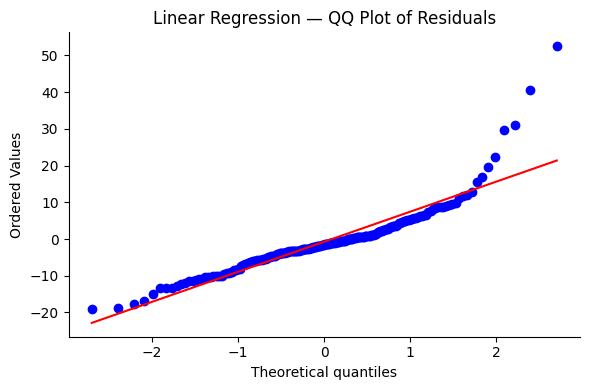

In [63]:
# 3) QQ-plot residual
plt.figure(figsize=(6,4))
stats.probplot(resid_lin, dist="norm", plot=plt)
plt.title("Linear Regression — QQ Plot of Residuals")
sns.despine()
plt.tight_layout()
plt.show()

### Random Forest

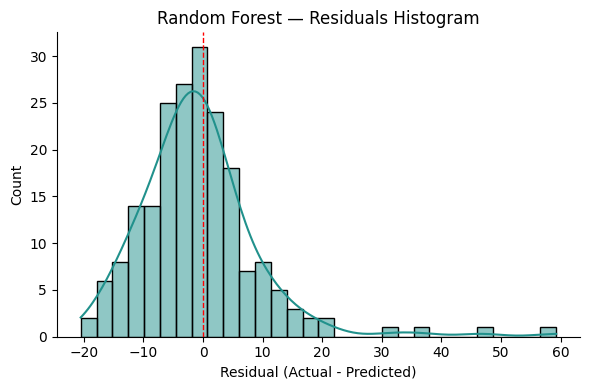

In [64]:
# --- Prediksi RF terbaik ---
y_pred_rf = best_rf.predict(X_test)
resid_rf  = y_test - y_pred_rf
fitted_rf = y_pred_rf

# 1) Histogram residual
plt.figure(figsize=(6,4))
sns.histplot(resid_rf, kde=True, bins=30, color=sns.color_palette("viridis", 3)[1])
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.title("Random Forest — Residuals Histogram")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
sns.despine()
plt.tight_layout()
plt.show()

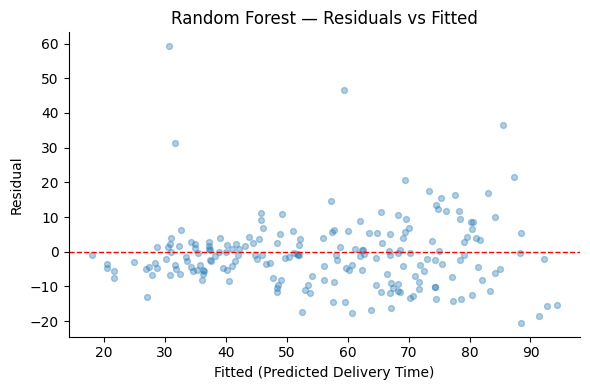

In [65]:

# 2) Residuals vs Fitted
plt.figure(figsize=(6,4))
plt.scatter(fitted_rf, resid_rf, alpha=0.35, s=18)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Random Forest — Residuals vs Fitted")
plt.xlabel("Fitted (Predicted Delivery Time)")
plt.ylabel("Residual")
sns.despine()
plt.tight_layout()
plt.show()

- Random Forest tidak mampu mengatasi kasus delivery time panjang dengan baik, terlihat dari underprediction sistematis.

- Dibanding Linear Regression, pola residual RF lebih "bias" ke bawah di fitted tinggi.

- Hal ini menjelaskan mengapa metrik evaluasi RF lebih buruk (MAE, RMSE lebih besar, R² lebih rendah).

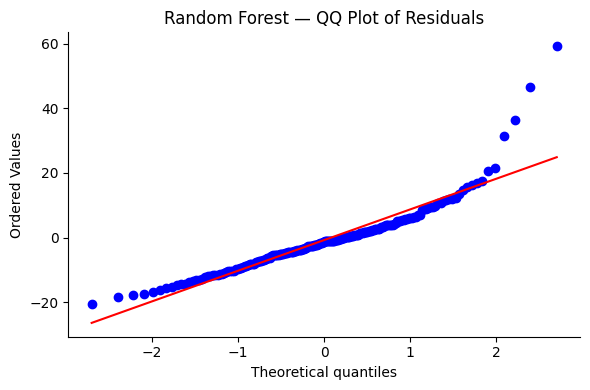

In [66]:

# 3) QQ-plot residual
plt.figure(figsize=(6,4))
stats.probplot(resid_rf, dist="norm", plot=plt)
plt.title("Random Forest — QQ Plot of Residuals")
sns.despine()
plt.tight_layout()
plt.show()

### XGBoost

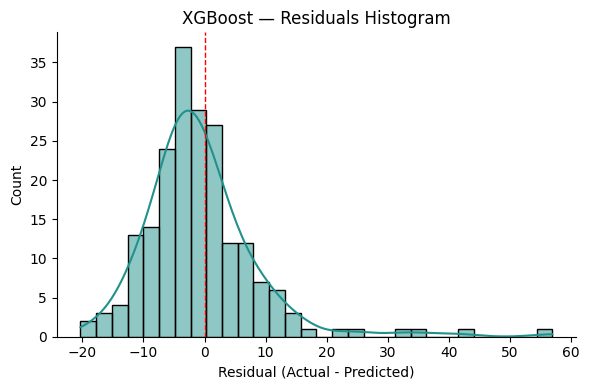

In [67]:
# --- Prediksi XGB terbaik ---
y_pred_xgb = best_xgb.predict(X_test)
resid_xgb  = y_test - y_pred_xgb
fitted_xgb = y_pred_xgb

# 1) Histogram residual
plt.figure(figsize=(6,4))
sns.histplot(resid_xgb, kde=True, bins=30, color=sns.color_palette("viridis", 3)[1])
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.title("XGBoost — Residuals Histogram")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
sns.despine()
plt.tight_layout()
plt.show()

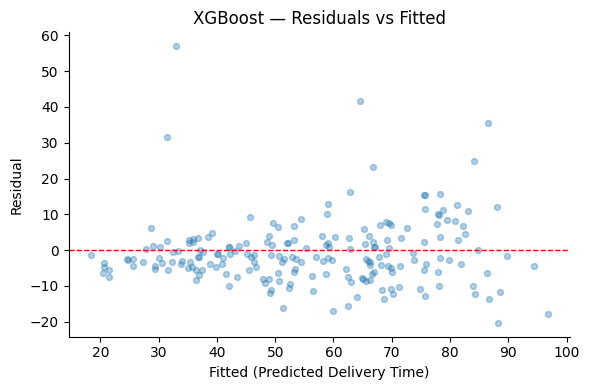

In [68]:
# 2) Residuals vs Fitted
plt.figure(figsize=(6,4))
plt.scatter(fitted_xgb, resid_xgb, alpha=0.35, s=18)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("XGBoost — Residuals vs Fitted")
plt.xlabel("Fitted (Predicted Delivery Time)")
plt.ylabel("Residual")
sns.despine()
plt.tight_layout()
plt.show()

1. XGBoost punya pola residual terbaik dibanding RF & Linear Regression:

- Error acak → model generalisasi lebih baik.

- Sebaran residual lebih sempit → prediksi lebih konsisten.

- Outlier tetap ada, tapi tidak seburuk RF.

2. Hal ini sejalan dengan metrik evaluasi → XGBoost unggul dengan MAE & RMSE terendah, serta R² tertinggi (0.80).

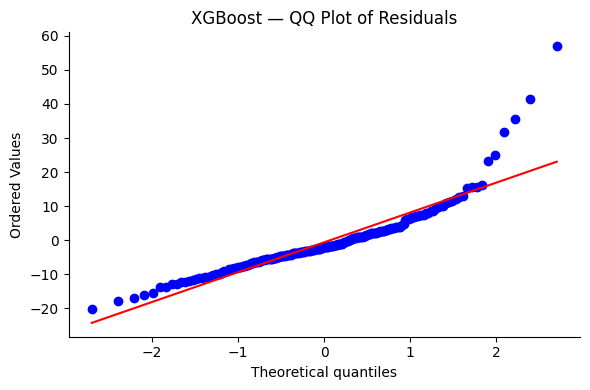

In [69]:
# 3) QQ-plot residual
plt.figure(figsize=(6,4))
stats.probplot(resid_xgb, dist="norm", plot=plt)
plt.title("XGBoost — QQ Plot of Residuals")
sns.despine()
plt.tight_layout()
plt.show()

## Feature Importance / Interpretation Coefficien

### Linear Regression

In [78]:
# --- Ambil nama fitur dari preprocessor ---
ohe = linreg.named_steps['preprocessor'].transformers_[0][1]  # OneHotEncoder
ohe_features = ohe.get_feature_names_out(categorical_cols)
all_features = list(ohe_features) + numeric_cols

# --- Ambil koefisien ---
coefs = linreg.named_steps['regressor'].coef_
coef_df = pd.DataFrame({'feature': all_features, 'coef': coefs})

# Sort by absolute value (biar paling berpengaruh di atas)
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=True)

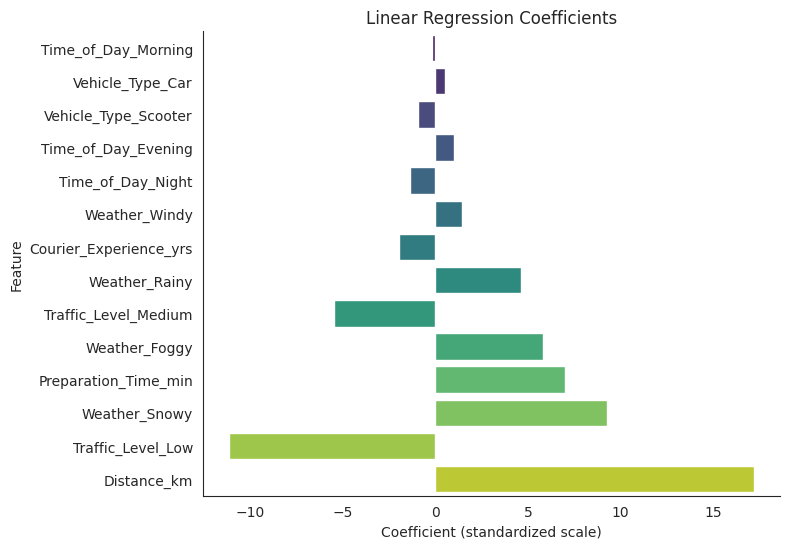

In [80]:
# --- Plot ---
plt.figure(figsize=(8, max(5, 0.4*len(coef_df))))  # tinggi dinamis
sns.barplot(data=coef_df, x='coef', y='feature', palette='viridis')
plt.title('Linear Regression Coefficients')
plt.xlabel('Coefficient (standardized scale)')
plt.ylabel('Feature')
sns.despine()
plt.tight_layout()
plt.show()

**Interpretasi Coefficients**

1. Faktor paling berpengaruh positif:

- Distance_km (+17.17) → faktor utama yang meningkatkan waktu pengantaran. Logis: semakin jauh jarak, semakin lama waktu antar.

- Weather_Snowy (+9.25) dan Preparation_Time_min (+7.00) → cuaca salju dan waktu persiapan dapur jelas memperlambat delivery.

- Weather_Foggy (+6.00) dan Weather_Rainy (+4.64) → cuaca buruk menambah delay.

2. Faktor paling berpengaruh negatif:

- Traffic_Level_Low (−11.13) → kondisi jalan lancar sangat mengurangi waktu pengiriman, sesuai ekspektasi.

- Traffic_Level_Medium (−5.45) juga sedikit mempercepat relatif terhadap kondisi lain, meski efeknya lebih kecil.

- Courier_Experience_yrs (−1.96) → kurir berpengalaman cenderung lebih cepat, walau pengaruhnya kecil.

3. Faktor dengan pengaruh relatif kecil:

- Time_of_Day (Morning, Evening, Night) dan Vehicle_Type (Car, Scooter) → efeknya ada, tapi jauh lebih kecil dibanding faktor utama (jarak, cuaca, dan traffic).

# For Deployment (Streamlit)

In [81]:
import json, joblib
import numpy as np


# --- Save model pipeline
joblib.dump(linreg, "model_linreg_pipeline.pkl")
print("Saved: model_linreg_pipeline.pkl")

# --- Ekstrak kategori dari OneHotEncoder di preprocessor (robust by name)
def get_ohe_and_cats(pipeline, cat_transformer_name="cat"):
    pre = pipeline.named_steps["preprocessor"]
    # cari transformer bernama "cat"
    for name, trans, cols in pre.transformers_:
        if name == cat_transformer_name:
            ohe = trans
            cat_cols = cols
            break
    else:
        raise RuntimeError("Transformer 'cat' tidak ditemukan di preprocessor")

    # pastikan sudah fit (punya .categories_)
    cats = {col: cat.tolist() for col, cat in zip(cat_cols, ohe.categories_)}
    return cats

cats = get_ohe_and_cats(linreg, cat_transformer_name="cat")  # ganti jika namanya beda
with open("categories.json", "w") as f:
    json.dump(cats, f)

print("Saved: categories.json")

Saved: model_linreg_pipeline.pkl
Saved: categories.json


In [82]:
import sklearn, numpy, pandas, scipy; print({
    "sklearn": sklearn.__version__,
    "numpy": numpy.__version__,
    "pandas": pandas.__version__,
    "scipy": scipy.__version__,
})

{'sklearn': '1.6.1', 'numpy': '2.0.2', 'pandas': '2.2.2', 'scipy': '1.16.2'}
